In [5]:
import sys
sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [2]:
baseline_K_val = [i for i in range(len(config.dataset_sub_B))]
SUBJECT = "Brian"


ACC_lst = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
ERROR! Session/line number was not unique in database. History logging moved to new session 3952
Returning K-th session data: Exp_2025-07-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151] 0/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-07-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151, 0.4377838373184204] 1/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Dataset 3/14 - Session Exp_2025-07-09-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-07-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151, 0.4377838373184204, 0.6800172328948975] 2/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Dataset 3/14 - Session

In [7]:
baseline_K_val = [i for i in range(len(config.dataset_sub_B))]
SUBJECT = "Brian"

ACC_lst_target = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, X_test, y_test = trainer.return_K_th_data_only(K, train_ratio=0.7)
    X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst_target.append(acc)
    print(ACC_lst_target, f"{i}/{len(baseline_K_val)}\n\n")
    #pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Returning K-th session data: Exp_2025-06-27-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595] 0/14


Returning K-th session data: Exp_2025-07-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835] 1/14


Returning K-th session data: Exp_2025-07-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496] 2/14


Returning K-th session data: Exp_2025-07-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.9455128312110901] 3/14


Returning K-th session data: Exp_2025-07-10-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.9455128312110901, 0.8938053250312805] 4/14


Returning K-th session data: Exp_2025-07-16-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.945

In [8]:
ACC_lst_target

[0.9100528955459595,
 0.9567901492118835,
 0.8497023582458496,
 0.9455128312110901,
 0.8938053250312805,
 0.9172494411468506,
 0.9448924660682678,
 0.9454277157783508,
 0.9497126340866089,
 0.9272727370262146,
 0.9219576716423035,
 0.9608585834503174]

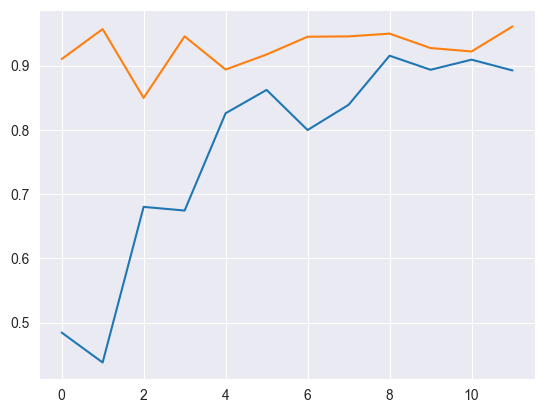

In [9]:
plt.plot(ACC_lst)
plt.plot(ACC_lst_target)

In [ ]:
for idx, x in enumerate([Init_acc_all, Prev_acc_all, Trained_acc_all]):
    if idx==0:
        print(f"Average of acc without training anything (should be random): {np.mean(x)*100:.2f}%")
    elif idx==1:
        print(f"Average of acc using previous test data after training: {np.mean(x)*100:.2f}%")
    elif idx==2:
        print(f"Average of acc using current test data after training: {np.mean(x)*100:.2f}%")
for idx, b in enumerate(baselines):
    val = float(np.mean(pd.read_csv(baselines[idx])['Accuracy'][int(baseline_K[idx]):]))
    print(f"K-{baseline_K[idx]}: {val:.2f}% | Target: {np.mean(Trained_acc_all[int(baseline_K[idx]):])*100:.2f}")

In [ ]:
import matplotlib.pyplot as plt

Trained_acc_all_stored = [0.823392927646637, 0.904861569404602, 0.9424460530281067, 0.9048944711685181, 0.9240977764129639, 0.9116214513778687, 0.946840763092041, 0.9351787567138672, 0.947931170463562, 0.9429366588592529, 0.9534506797790527, 0.9413134455680847, 0.959462583065033, 0.9099767804145813]

X_labels = ['Stand (6/27)', 'Sit_chair (6/27)', 'Stand (7/9)', 'Sit_chair (7/9)', 'Stand (7/10)', 'Sit_chair (7/10)',
            'Stand (7/16)', 'Sit_chair (7/16)', 'Stand (7/17)', 'Sit_chair (7/17)', 'Stand (7/24)', 'Sit_chair (7/24)', 'Stand (8/1)', 'Sit_chair (8/1)']

plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(14, 7), dpi=150)
#plt.title('Training from scratch every time', fontsize=15)
plt.plot(Trained_acc_all_stored, c='red', label='Train/Test in same session', marker='o', linestyle='--')
for idx, base in enumerate(baselines):
    baseline_result = pd.read_csv(base)
    plt.plot(X_labels, baseline_result['Accuracy'] / 100, marker='^', label=f'K={baseline_K[idx]}', linestyle='-')

plt.ylim([0, 1])
plt.xlabel('Date (Sessions)', fontsize=14)
plt.ylabel('Test Accuracy', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.legend(fontsize=16, ncol=1, loc='lower right')
plt.grid(True, linestyle='--', color='lightgrey')
plt.tight_layout()
plt.show()